# Sketchy Parking Lot EDA

In [ ]:
# Import and setup
import json
import os
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Domain parsing
import tldextract

# Text analysis
import re
from collections import Counter
from math import log2
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

## Import Data and Preparation

In [2]:
'''
recursively load data
'''

data_location = '../data/parked_suspicious/'

# Load summary
with open(f"{data_location}_summary.json") as f:
    summary = json.load(f)

dfs = []

# Iterate over summary labels to combine all JSONL files
for label in summary.keys():
    clean_label = label.replace(':', '-')

    filename = f"{data_location + clean_label}.jsonl"
    
    if not os.path.exists(filename):
        print(f"Missing: {filename}")
        continue
    
    try:
        df = pd.read_json(filename, lines=True)
        dfs.append(df)
        print(f"Loaded {filename} ({len(df)} rows)")
        
    except ValueError as e:
        print(f"Error reading {filename}: {e}")

# Combine all JSONL files into single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(combined_df))
print("Services:", combined_df["service"].value_counts())

Loaded ../data/parked_suspicious/other-unclassified.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-empty-title.jsonl (1000 rows)
Loaded ../data/parked_suspicious/default-server.jsonl (1000 rows)
Loaded ../data/parked_suspicious/sedo.jsonl (1000 rows)
Loaded ../data/parked_suspicious/searchhounds.jsonl (1000 rows)
Loaded ../data/parked_suspicious/wix-unconnected.jsonl (1000 rows)
Loaded ../data/parked_suspicious/hugedomains.jsonl (1000 rows)
Loaded ../data/parked_suspicious/godaddy.jsonl (1000 rows)
Loaded ../data/parked_suspicious/afternic.jsonl (1000 rows)
Loaded ../data/parked_suspicious/expired-domain.jsonl (1000 rows)
Loaded ../data/parked_suspicious/atom.jsonl (1000 rows)
Loaded ../data/parked_suspicious/spaceship.jsonl (1000 rows)
Loaded ../data/parked_suspicious/other-domain-as-title.jsonl (642 rows)
Loaded ../data/parked_suspicious/dynadot.jsonl (619 rows)
Loaded ../data/parked_suspicious/brandbucket.jsonl (440 rows)
Loaded ../data/parked_suspicious/default-nginx.json

In [3]:
combined_df.head()

,url,domain,service,hops,redirectChain,finalUrl,title,textSnippet
0,http://aaa-fuerteventura-appartments.com,aaa-fuerteventura-appartments.com,other:unclassified,5,[{'from': 'https://aaa-fuerteventura-appartmen...,https://welcome.mywebsite-editor.com/render/ww...,Bald verfügbar,Bald verfügbar
1,http://a-afolienfahrzeuge.at,a-afolienfahrzeuge.at,other:unclassified,3,"[{'from': 'https://a-afolienfahrzeuge.at', 'to...",https://www.a-afolienfahrzeuge.at/,Connect Your Domain,Connect Your Domain You're almost done! Your c...
2,http://a-lola-estilo.com,a-lola-estilo.com,other:unclassified,3,"[{'from': 'https://a-lola-estilo.com', 'to': '...",https://www.a-lola-estilo.com/password,A Lola Estilo – Abertura em breve,A Lola Estilo – Abertura em breve A Lola Estil...
3,http://a-petrenko.com,a-petrenko.com,other:unclassified,3,"[{'from': 'https://a-petrenko.com', 'to': 'htt...",https://a-petrenko.com/info/,a-petrenko,a-petrenko
4,http://a-point-of-view.de,a-point-of-view.de,other:unclassified,3,"[{'from': 'https://a-point-of-view.de', 'to': ...",https://p2m-1.forsaledomain.net/true2.php?id=a...,Just a moment...,Just a moment... p2m-1.forsaledomain.net Verif...


In [4]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15673 entries, 0 to 15672
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   url            15673 non-null  object
 1   domain         15673 non-null  object
 2   service        15673 non-null  object
 3   hops           15673 non-null  int64 
 4   redirectChain  15673 non-null  object
 5   finalUrl       15673 non-null  object
 6   title          15673 non-null  object
 7   textSnippet    15673 non-null  object
dtypes: int64(1), object(7)
memory usage: 979.7+ KB


In [5]:
combined_df.describe()

,hops
count,15673.000000
mean,0.710202
std,0.998587
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,5.000000


## Text Analysis for Identification of Parked or Ad Domains 

In [6]:
'''
combine, clean, and tokenize
'''
text_cols = ["title", "textSnippet"]

def preprocess_text(row, text_cols):
    if not text_cols:
        return "", []
    
    combined = " ".join([str(row[col]) for col in text_cols if pd.notna(row[col])])

    # will explore other tokenization methods 
    combined = combined.strip().lower()
    combined = re.sub(r"http\S+|www\.\S+", " ", combined)
    combined = re.sub(r"[^a-z0-9\s]", " ", combined)
    combined = re.sub(r"\s+", " ", combined).strip()
    
    # Tokenize
    tokens = combined.split()
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return combined, tokens

combined_df[["clean_text", "tokens"]] = combined_df.apply(
    lambda row: pd.Series(preprocess_text(row, text_cols)),
    axis=1
)

combined_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,bald verf gbar bald verf gbar,"[bald, verf, gbar, bald, verf, gbar]"
1,connect your domain connect your domain you re...,"[connect, domain, connect, domain, almost, don..."
2,a lola estilo abertura em breve a lola estilo ...,"[lola, estilo, abertura, em, breve, lola, esti..."
3,a petrenko a petrenko,"[petrenko, petrenko]"
4,just a moment just a moment p2m 1 forsaledomai...,"[moment, moment, p2m, 1, forsaledomain, net, v..."


In [7]:
'''
bag of words and term frequency
'''

def compute_bow(tokens):
    return Counter(tokens)

def compute_tf(bow):
    total_tokens = sum(bow.values())
    return {word: count / total_tokens for word, count in bow.items()}

combined_df["bow"] = combined_df["tokens"].apply(compute_bow)
combined_df["tf"] = combined_df["bow"].apply(compute_tf)
combined_df[["bow", "tf"]].head()

,bow,tf
0,"{'bald': 2, 'verf': 2, 'gbar': 2}","{'bald': 0.3333333333333333, 'verf': 0.3333333..."
1,"{'connect': 3, 'domain': 4, 'almost': 1, 'done...","{'connect': 0.16666666666666666, 'domain': 0.2..."
2,"{'lola': 3, 'estilo': 3, 'abertura': 2, 'em': ...","{'lola': 0.08571428571428572, 'estilo': 0.0857..."
3,{'petrenko': 2},{'petrenko': 1.0}
4,"{'moment': 2, 'p2m': 2, '1': 2, 'forsaledomain...","{'moment': 0.09523809523809523, 'p2m': 0.09523..."


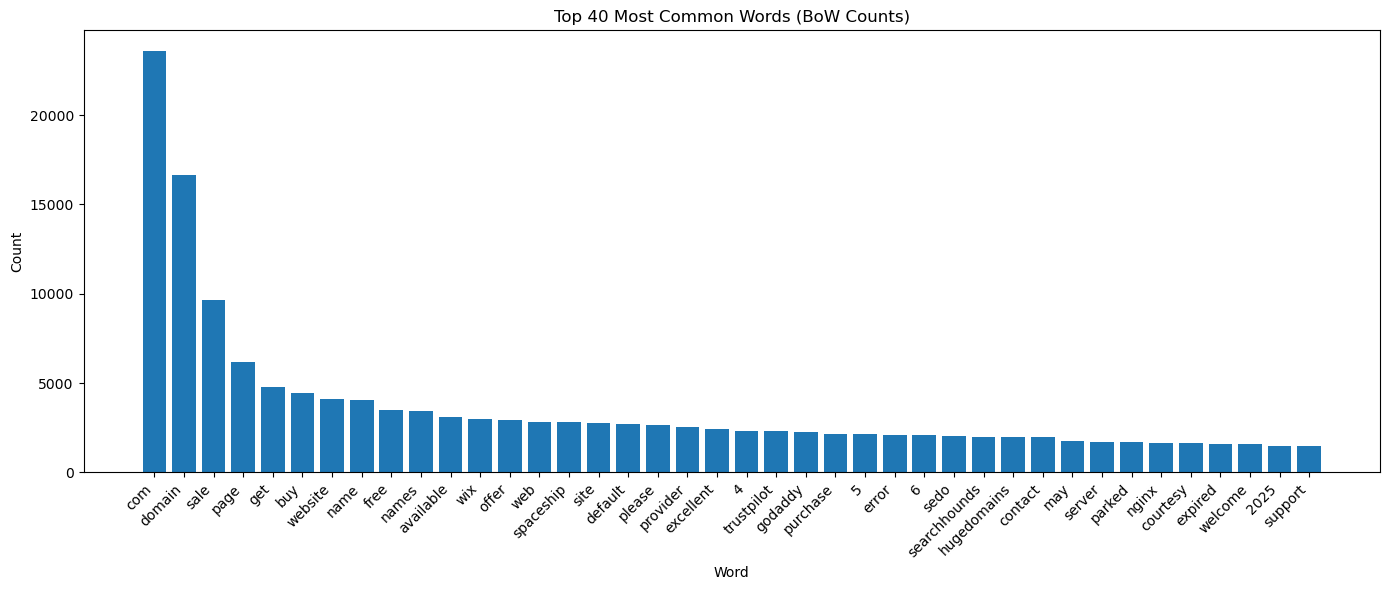

In [8]:
'''
Distribution of term frequencies
'''
# Aggregate all "bag of words" most common words
total_bow = Counter()

for bow in combined_df["bow"]:
    total_bow.update(bow)

# Display top N terms
top_n = 40
top_terms = total_bow.most_common(top_n)
top_df = pd.DataFrame(top_terms, columns=["term", "count"])

# Plot
plt.figure(figsize=(14, 6))
plt.bar(top_df["term"], top_df["count"])
plt.title(f"Top {top_n} Most Common Words (BoW Counts)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

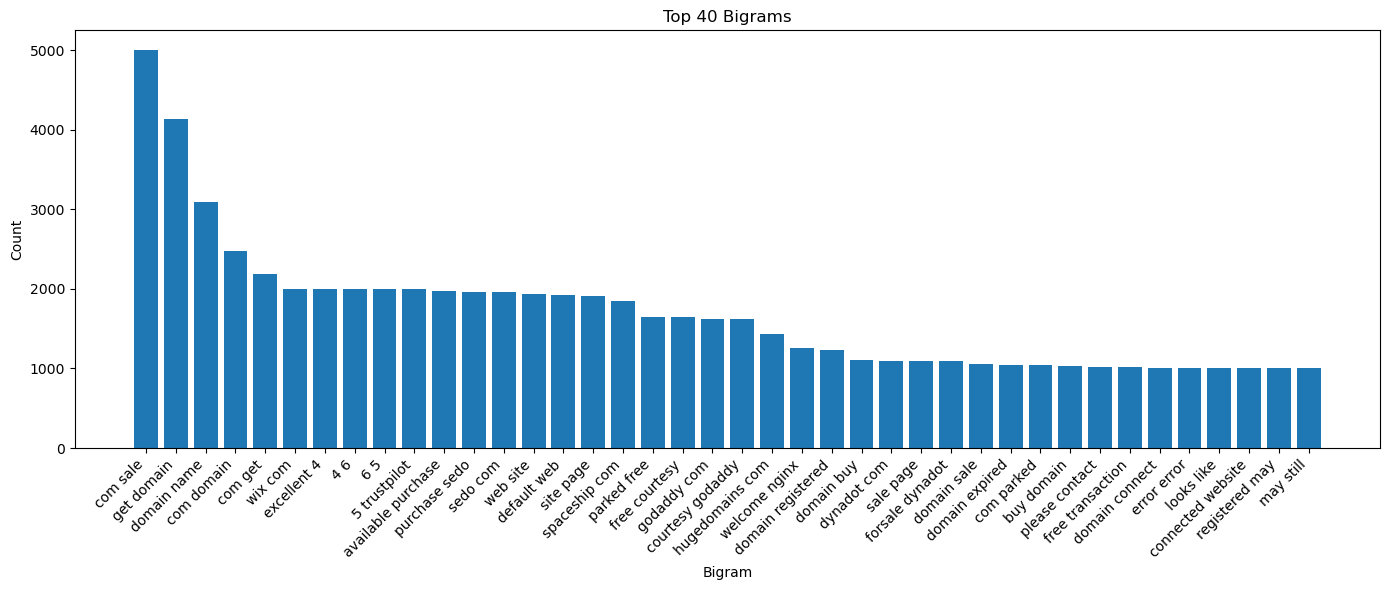

In [9]:
'''
Generate bigrams
'''

def get_bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

# Create bigrams column
combined_df["bigrams"] = combined_df["tokens"].apply(get_bigrams)

total_bigrams = Counter()

for bigram_list in combined_df["bigrams"]:
    total_bigrams.update(bigram_list)


top_n = 40
top_bigrams = total_bigrams.most_common(top_n)

top_df = pd.DataFrame(top_bigrams, columns=["bigram", "count"])
top_df["bigram"] = top_df["bigram"].apply(lambda x: " ".join(x))

plt.figure(figsize=(14, 6))
plt.bar(top_df["bigram"], top_df["count"])
plt.title(f"Top {top_n} Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

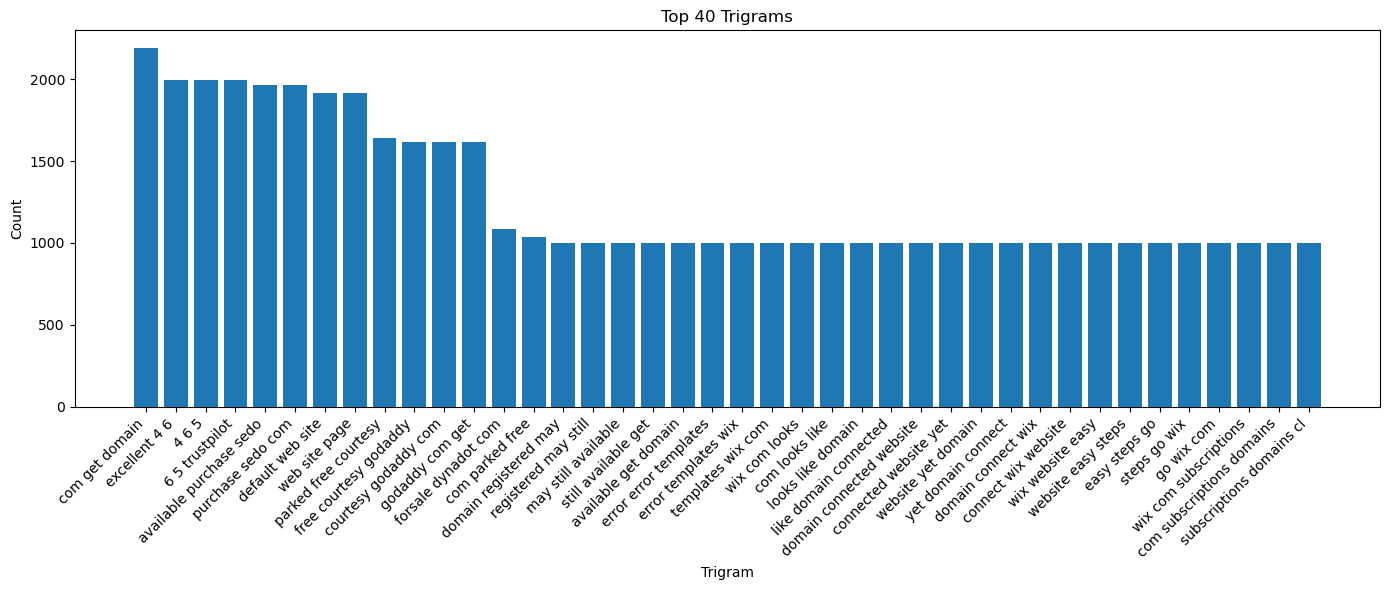

In [10]:
'''
Generate trigrams
'''

def get_trigrams(tokens):
    return list(zip(tokens, tokens[1:], tokens[2:]))

# Create trigrams column
combined_df["trigrams"] = combined_df["tokens"].apply(get_trigrams)

total_trigrams = Counter()

for trigram_list in combined_df["trigrams"]:
    total_trigrams.update(trigram_list)

top_n = 40
top_trigrams = total_trigrams.most_common(top_n)
top_df = pd.DataFrame(top_trigrams, columns=["trigram", "count"])

# Convert tuples to strings
top_df["trigram"] = top_df["trigram"].apply(lambda x: " ".join(x))

plt.figure(figsize=(14, 6))
plt.bar(top_df["trigram"], top_df["count"])
plt.title(f"Top {top_n} Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
'''
Start of keywords for experimentation
'''
ad_keywords = {
    "ad", "ads", "advertisement", "sponsored", "promotion",
    "click", "offer", "sale", "buy", "discount"
}

parked_keywords = {
    "domain for sale", "buy this domain", "this domain is for sale",
    "parked", "coming soon", "under construction", "related links", "related searches", 
    "search results", "powered by", "ads by", "privacy policy", "this webpage was generated",
    "domain parked free", "listing expired"
}

suspicious_keywords = {
    "virus", "malware", "warning", "security alert", "download now", "install", 
    "verify", "urgent", "your computer", "system alert", "scan now", "risk detected",
    "click here to continue", "enable notifications"
}
print(f"Ad keywords: {len(ad_keywords)}\n", ad_keywords)
print(f"Parked keywords: {len(parked_keywords)}\n", parked_keywords)
print(f"Suspicious keywords: {len(suspicious_keywords)}\n", suspicious_keywords)

Ad keywords: 10
 {'advertisement', 'sponsored', 'sale', 'promotion', 'discount', 'ads', 'click', 'buy', 'ad', 'offer'}
Parked keywords: 15
 {'search results', 'related links', 'privacy policy', 'domain parked free', 'this webpage was generated', 'ads by', 'this domain is for sale', 'parked', 'related searches', 'coming soon', 'domain for sale', 'under construction', 'buy this domain', 'powered by', 'listing expired'}
Suspicious keywords: 14
 {'download now', 'virus', 'install', 'risk detected', 'enable notifications', 'urgent', 'scan now', 'your computer', 'malware', 'click here to continue', 'system alert', 'verify', 'security alert', 'warning'}


In [12]:
'''
Expand on Keywords with bigrams and trigrams
'''

# top n-grams into searchable strings
bigram_list = [" ".join(bg) for bg, _ in total_bigrams.most_common(100)]
trigram_list = [" ".join(tg) for tg, _ in total_trigrams.most_common(100)]

all_ngrams = set(bigram_list + trigram_list)

# Expand keyword sets using pattern matching
def expand_keywords(seed_keywords, ngrams):
    expanded = set(seed_keywords)
    
    for phrase in ngrams:
        for keyword in seed_keywords:
            if keyword in phrase:
                expanded.add(phrase)
    
    return expanded

expanded_ads = expand_keywords(ad_keywords, all_ngrams)
expanded_parked = expand_keywords(parked_keywords, all_ngrams)
expanded_suspicious = expand_keywords(suspicious_keywords, all_ngrams)

print(f"Expanded Ad Keywords: {len(expanded_ads)}\n", expanded_ads)
print(f"\nExpanded Parked Keywords: {len(expanded_parked)}\n", expanded_parked)
print(f"\nExpanded Suspicious Keywords: {len(expanded_suspicious)}\n", expanded_suspicious)

Expanded Ad Keywords: 38
 {'domain sale', 'squadhelp atom', 'promotion', 'discount', 'page ip address', 'forsale dynadot com', 'sale spaceship com', 'com sale brandbucket', 'sale spaceship', 'sponsored', 'dynadot com', 'sale page', 'sale brandbucket', 'sale get', 'sale get domain', 'godaddy com', 'offer', 'forsale dynadot', 'squadhelp atom everything', 'courtesy godaddy', 'ads', 'sale squadhelp atom', 'courtesy godaddy com', 'buy', 'advertisement', 'com sale squadhelp', 'identify provider click', 'com sale', 'sale', 'free courtesy godaddy', 'domain buy', 'make offer', 'click', 'sale squadhelp', 'offer buy', 'godaddy com get', 'ad', 'buy domain'}

Expanded Parked Keywords: 19
 {'search results', 'domain parked free', 'ads by', 'parked', 'domain for sale', 'powered by', 'privacy policy', 'parked free', 'this domain is for sale', 'under construction', 'buy this domain', 'this webpage was generated', 'related searches', 'coming soon', 'parked free courtesy', 'related links', 'com parked fr

In [13]:
def keyword_score(tokens, keyword_set):
    text = " ".join(tokens)
    return sum(1 for kw in keyword_set if kw in text)

combined_df["ad_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_ads))
combined_df["parked_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_parked))
combined_df["suspicious_score"] = combined_df["tokens"].apply(lambda x: keyword_score(x, expanded_suspicious))
combined_df[["ad_score", "parked_score", "suspicious_score"]].head(50)


,ad_score,parked_score,suspicious_score
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,1,0,1
5,1,0,1
6,1,0,1
7,3,0,0
8,0,0,0
9,5,0,0


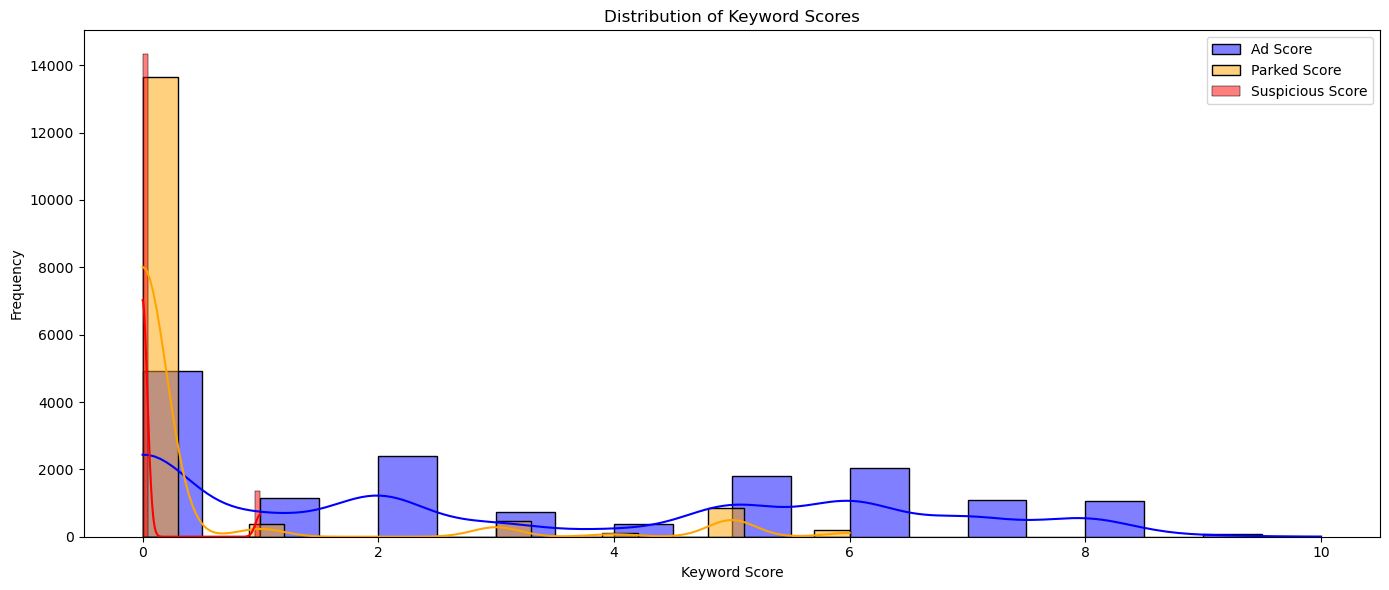

In [26]:
# Analyze score distributions
plt.figure(figsize=(14, 6))
sns.histplot(combined_df["ad_score"], bins=20, kde=True, color="blue", label="Ad Score")
sns.histplot(combined_df["parked_score"], bins=20, kde=True, color="orange", label="Parked Score")
sns.histplot(combined_df["suspicious_score"], bins=20, kde=True, color="red", label="Suspicious Score")
plt.title("Distribution of Keyword Scores")
plt.xlabel("Keyword Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Data Wrangling

Feature engineer

In [15]:
'''
extract TLD, domain and subdomain using tldextract

Parse the full domain for analysis.
'''
# change domain to domain_full to preserve original domain for tldextract
combined_df["domain_full"] = combined_df["domain"]
combined_df.drop("domain", axis=1, inplace=True)

def extract_domain_parts(domain):
    ext = tldextract.extract(domain)
    return pd.Series({
        "subdomain": ext.subdomain,
        "domain_name": ext.domain,
        "tld": ext.suffix
    })

combined_df[["subdomain", "domain_name", "tld"]] = combined_df["domain_full"].apply(extract_domain_parts)

In [16]:
'''
domain length feature

Identify how many characters the domain has.
'''
combined_df["len_domain_full"] = combined_df["domain_full"].apply(len)

In [17]:
'''
is_suspicious feature

This feature is derived from the amount of hops (redirects) domain has.
If a domain has more than 2 hops, we can consider it suspicious.
Subject to change based on analysis of hops distribution.
'''
threshold_hops = 2
combined_df["is_suspicious"] = combined_df["hops"].apply(lambda x: 1 if x > threshold_hops else 0)

In [18]:
'''
Shannons entropy of the domain feature

Calculate the Shannon entropy of the domain name to measure its randomness.
Higher entropy may indicate a more complex and potentially suspicious domain.
'''


'\nShannons entropy of the domain feature\n\nCalculate the Shannon entropy of the domain name to measure its randomness.\nHigher entropy may indicate a more complex and potentially suspicious domain.\n'

In [19]:
combined_df.head()

,url,service,hops,redirectChain,finalUrl,title,textSnippet,clean_text,tokens,bow,...,trigrams,ad_score,parked_score,suspicious_score,domain_full,subdomain,domain_name,tld,len_domain_full,is_suspicious
0,http://aaa-fuerteventura-appartments.com,other:unclassified,5,[{'from': 'https://aaa-fuerteventura-appartmen...,https://welcome.mywebsite-editor.com/render/ww...,Bald verfügbar,Bald verfügbar,bald verf gbar bald verf gbar,"[bald, verf, gbar, bald, verf, gbar]","{'bald': 2, 'verf': 2, 'gbar': 2}",...,"[(bald, verf, gbar), (verf, gbar, bald), (gbar...",0,0,0,aaa-fuerteventura-appartments.com,,aaa-fuerteventura-appartments,com,33,1
1,http://a-afolienfahrzeuge.at,other:unclassified,3,"[{'from': 'https://a-afolienfahrzeuge.at', 'to...",https://www.a-afolienfahrzeuge.at/,Connect Your Domain,Connect Your Domain You're almost done! Your c...,connect your domain connect your domain you re...,"[connect, domain, connect, domain, almost, don...","{'connect': 3, 'domain': 4, 'almost': 1, 'done...",...,"[(connect, domain, connect), (domain, connect,...",0,0,0,a-afolienfahrzeuge.at,,a-afolienfahrzeuge,at,21,1
2,http://a-lola-estilo.com,other:unclassified,3,"[{'from': 'https://a-lola-estilo.com', 'to': '...",https://www.a-lola-estilo.com/password,A Lola Estilo – Abertura em breve,A Lola Estilo – Abertura em breve A Lola Estil...,a lola estilo abertura em breve a lola estilo ...,"[lola, estilo, abertura, em, breve, lola, esti...","{'lola': 3, 'estilo': 3, 'abertura': 2, 'em': ...",...,"[(lola, estilo, abertura), (estilo, abertura, ...",0,0,0,a-lola-estilo.com,,a-lola-estilo,com,17,1
3,http://a-petrenko.com,other:unclassified,3,"[{'from': 'https://a-petrenko.com', 'to': 'htt...",https://a-petrenko.com/info/,a-petrenko,a-petrenko,a petrenko a petrenko,"[petrenko, petrenko]",{'petrenko': 2},...,[],0,0,0,a-petrenko.com,,a-petrenko,com,14,1
4,http://a-point-of-view.de,other:unclassified,3,"[{'from': 'https://a-point-of-view.de', 'to': ...",https://p2m-1.forsaledomain.net/true2.php?id=a...,Just a moment...,Just a moment... p2m-1.forsaledomain.net Verif...,just a moment just a moment p2m 1 forsaledomai...,"[moment, moment, p2m, 1, forsaledomain, net, v...","{'moment': 2, 'p2m': 2, '1': 2, 'forsaledomain...",...,"[(moment, moment, p2m), (moment, p2m, 1), (p2m...",1,0,1,a-point-of-view.de,,a-point-of-view,de,18,1


## Score and Classify Based on Engineered Features

Build a scoring model.

Classify as benign, suspicious, or high risk.

In [ ]:
'''
THE IDEA

threat_score = (
    0.4 * normalized_suspicious_score +
    0.3 * normalized_parked_score +
    0.2 * redirect_signal +
    0.1 * dns_signal
)

if threat_score > 0.7:
    label = "high_risk"
elif threat_score > 0.4:
    label = "suspicious"
else:
    label = "benign"
'''

'\nif threat_score > 0.7:\n    label = "high_risk"\nelif threat_score > 0.4:\n    label = "suspicious"\nelse:\n    label = "benign"\n'

## Data Distributions and Visualizations

In [21]:
combined_df.columns

Index(['url', 'service', 'hops', 'redirectChain', 'finalUrl', 'title',
       'textSnippet', 'clean_text', 'tokens', 'bow', 'tf', 'bigrams',
       'trigrams', 'ad_score', 'parked_score', 'suspicious_score',
       'domain_full', 'subdomain', 'domain_name', 'tld', 'len_domain_full',
       'is_suspicious'],
      dtype='object')

## Save JSONL

In [22]:
# save as JSONL for future use

# combined_df.to_json('data/parked_suspicious/_combined_data.jsonl', orient='records', lines=True)